Objective

To develop a regression model that predicts airline daily financial losses during aviation disruptions and analyze the operational factors contributing most to those losses.

In [22]:
# importing the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [23]:
#importing the dataset
airline = pd.read_csv('airline_losses_estimate.csv')

In [ ]:
#calling the dataset
airline

,airline,country,estimated_daily_loss_usd,cancelled_flights,rerouted_flights,additional_fuel_cost_usd,passengers_impacted
0,Emirates,UAE,4200000,18,62,2835200,9180
1,Qatar Airways,Qatar,3100000,12,41,1765800,6540
2,Etihad Airways,UAE,1800000,8,29,1023400,4320
3,Turkish Airlines,Turkey,2400000,14,38,1432600,7700
4,British Airways,UK,1950000,6,32,1185600,4680
5,Lufthansa,Germany,1650000,5,28,988000,3950
6,Air France,France,1420000,4,25,856000,3400
7,KLM,Netherlands,1180000,3,21,702800,2800
8,Singapore Airlines,Singapore,2100000,7,35,1274000,5110
9,Cathay Pacific,Hong Kong,1870000,6,31,1120600,4560


In [ ]:
#The .info() gives a quick summary of the structure of a dataset. 
# It helps you understand the dataset before doing analysis or modeling.
airline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   airline                   35 non-null     object
 1   country                   35 non-null     object
 2   estimated_daily_loss_usd  35 non-null     int64 
 3   cancelled_flights         35 non-null     int64 
 4   rerouted_flights          35 non-null     int64 
 5   additional_fuel_cost_usd  35 non-null     int64 
 6   passengers_impacted       35 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 2.0+ KB


In [ ]:
#.describe() is a quick statistical summary of our dataset.
airline.describe()

,estimated_daily_loss_usd,cancelled_flights,rerouted_flights,additional_fuel_cost_usd,passengers_impacted
count,3.500000e+01,35.000000,35.000000,3.500000e+01,35.000000
mean,1.395429e+06,5.571429,21.542857,7.887429e+05,3416.285714
std,8.218499e+05,3.632255,11.892516,5.160285e+05,1790.535716
min,3.800000e+05,2.000000,0.000000,0.000000e+00,1020.000000
25%,6.950000e+05,3.000000,12.000000,4.180000e+05,2260.000000
50%,1.340000e+06,5.000000,22.000000,7.680000e+05,3360.000000
75%,1.665000e+06,6.000000,27.500000,9.660000e+05,4010.000000
max,4.200000e+06,18.000000,62.000000,2.835200e+06,9180.000000


In [ ]:
#Checking for duplicates
airline.duplicated().sum()

np.int64(0)

#### This shows that this dataset has no duplicates.

In [ ]:
#checking for missing values
airline.isnull().sum()

airline                     0
country                     0
estimated_daily_loss_usd    0
cancelled_flights           0
rerouted_flights            0
additional_fuel_cost_usd    0
passengers_impacted         0
dtype: int64

#### This shows that this dataset has no missing values.

Text(0, 0.5, 'Values')

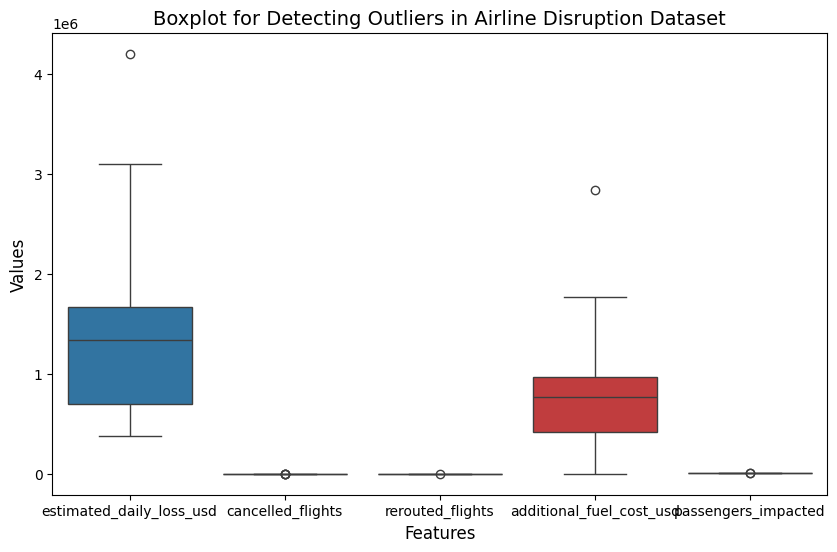

In [29]:
#checking for outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=airline)

# title and labels
plt.title("Boxplot for Detecting Outliers in Airline Disruption Dataset", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

#### From this boxplot, this dataset clearly contains outliers, especially in:

        estimated_daily_loss_usd

        additional_fuel_cost_usd

These outliers could represent:

        Major international airlines

        Airlines with the largest disruption exposure

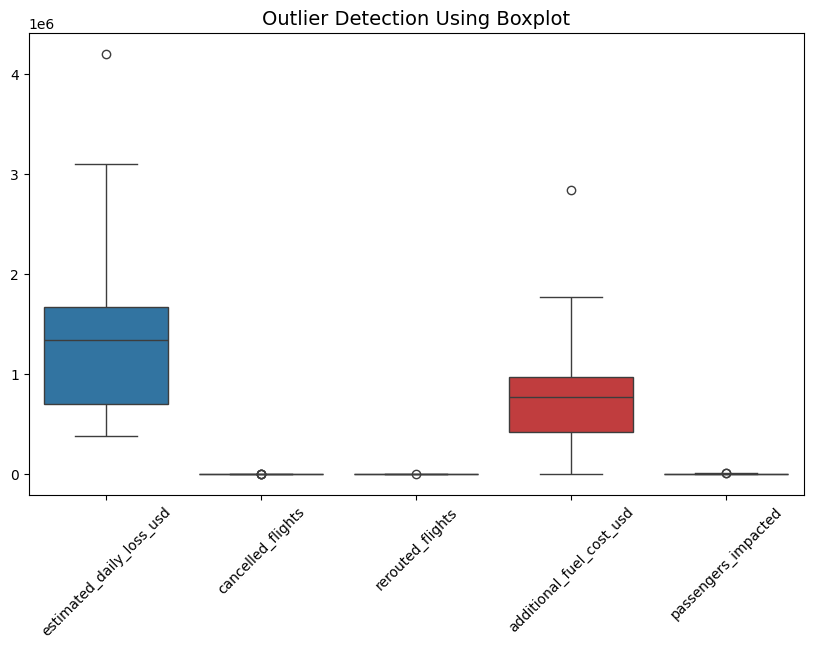

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(data=airline.select_dtypes(include='number'))

plt.title("Outlier Detection Using Boxplot", fontsize=14)
plt.xticks(rotation=45)

plt.show()

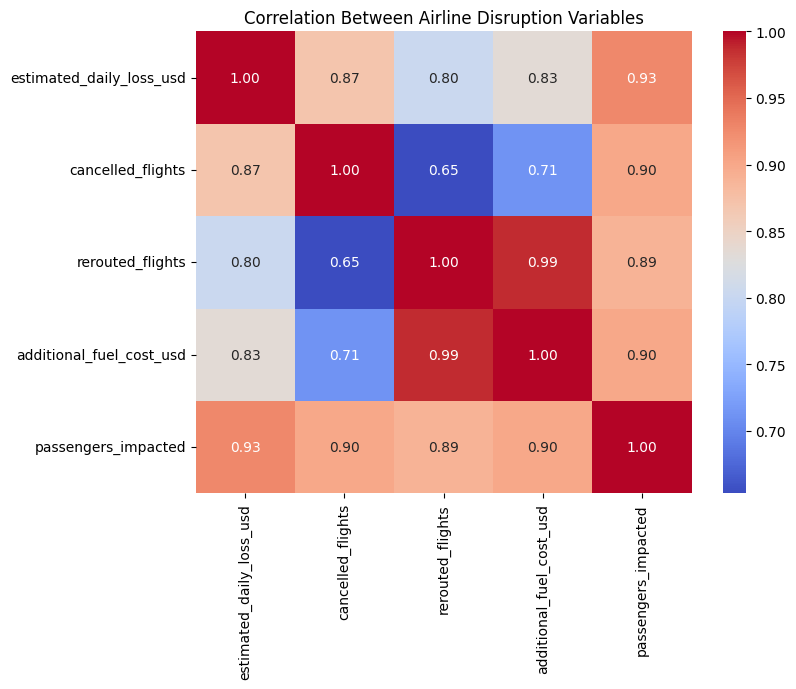

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    airline.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Airline Disruption Variables")
plt.show()

#### This heatmap shows the correlation between the numeric variables in my airline disruption dataset.

        Major drivers of airline financial loss

        1️⃣ Passengers impacted (0.93)
        2️⃣ Cancelled flights (0.87)
        3️⃣ Additional fuel cost (0.83)

        These variables strongly relate to financial losses.

In [32]:
#defining the x and y variables
y = airline['estimated_daily_loss_usd']
X = airline.drop('estimated_daily_loss_usd', axis=1)

In [45]:
X = pd.get_dummies(X, drop_first=True)

In [46]:
X = X.astype(int)
X

,cancelled_flights,rerouted_flights,additional_fuel_cost_usd,passengers_impacted,airline_Aeroflot,airline_Air China,airline_Air France,airline_Air India,airline_Asiana Airlines,airline_Austrian Airlines,...,country_Saudi Arabia,country_Scandinavia,country_Singapore,country_South Korea,country_Spain,country_Switzerland,country_Thailand,country_Turkey,country_UAE,country_UK
0,18,62,2835200,9180,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,12,41,1765800,6540,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8,29,1023400,4320,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,14,38,1432600,7700,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,6,32,1185600,4680,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,5,28,988000,3950,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,4,25,856000,3400,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,21,702800,2800,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,7,35,1274000,5110,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
9,6,31,1120600,4560,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
#splitting my data into test and training 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [66]:
from sklearn.tree import DecisionTreeRegressor 
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [67]:
#prediction 
y_pred = model.predict(X_test)

In [75]:
#Step 9: Evaluating my model
from sklearn.metrics import r2_score, root_mean_squared_error

print("Re Score: ", r2_score(y_test, y_pred))
print("RSME: ", root_mean_squared_error(y_test, y_pred))

Re Score:  0.8563286630254097
RSME:  131475.1470267833


##### The Decision Tree model performed strongly, achieving an R² score of 0.856, meaning it explained approximately 85.6% of the variation in airline financial losses during disruptions. The model's average prediction error was about $131,475, indicating relatively accurate forecasts considering the scale of the losses.

In [76]:
#checking if the model is overfitting or not
train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.9991068822231642
Test R2: 0.8563286630254097


In [77]:
#To analyze feature importance, this helps us to understand which exact feature has more influence on our target variable
importance = model.feature_importances_

features = pd.Series(importance, index=X_train.columns)

print(features.sort_values(ascending=False))

cancelled_flights           0.679068
additional_fuel_cost_usd    0.287238
rerouted_flights            0.011139
country_Turkey              0.010062
passengers_impacted         0.008261
                              ...   
country_Spain               0.000000
country_Switzerland         0.000000
country_Thailand            0.000000
country_UAE                 0.000000
country_UK                  0.000000
Length: 66, dtype: float64


##### Cancelled_flights and additional_fuel_cost_usd are the strongest drivers of airline financial losses during aviation disruptions.

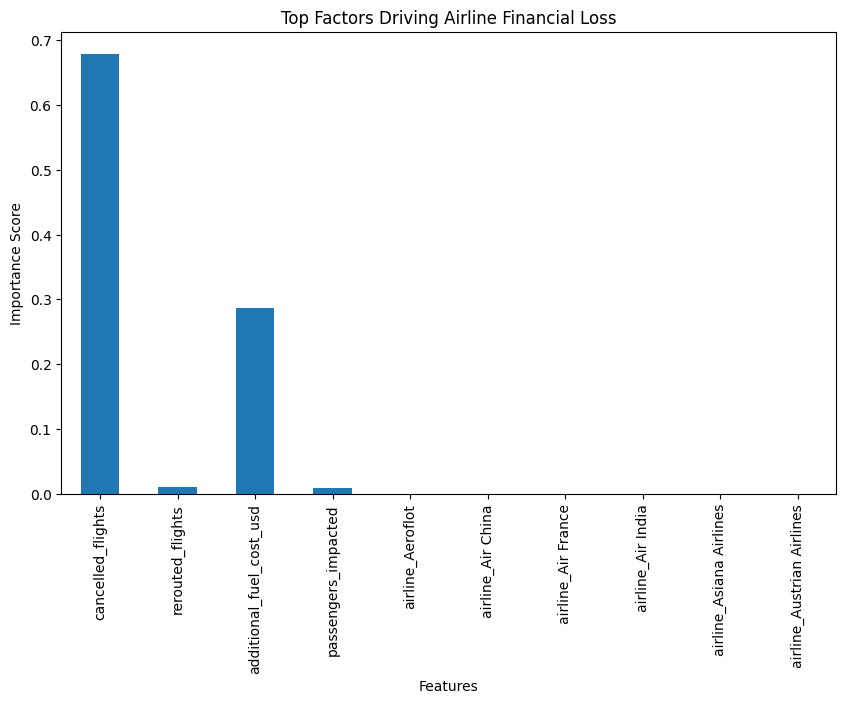

In [71]:
#Feature Importance Plot: This shows which operational factors drive airline losses the most.
plt.figure(figsize=(10,6))
features.head(10).plot(kind='bar')

plt.title("Top Factors Driving Airline Financial Loss")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, 'UAE'),
  Text(1, 0, 'Qatar'),
  Text(2, 0, 'Turkey'),
  Text(3, 0, 'UK'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'France'),
  Text(6, 0, 'Netherlands'),
  Text(7, 0, 'Singapore'),
  Text(8, 0, 'Hong Kong'),
  Text(9, 0, 'Malaysia'),
  Text(10, 0, 'India'),
  Text(11, 0, 'Pakistan'),
  Text(12, 0, 'Saudi Arabia'),
  Text(13, 0, 'Bahrain'),
  Text(14, 0, 'Oman'),
  Text(15, 0, 'South Korea'),
  Text(16, 0, 'Japan'),
  Text(17, 0, 'Thailand'),
  Text(18, 0, 'Russia'),
  Text(19, 0, 'Israel'),
  Text(20, 0, 'Jordan'),
  Text(21, 0, 'Egypt'),
  Text(22, 0, 'Spain'),
  Text(23, 0, 'Austria'),
  Text(24, 0, 'Switzerland'),
  Text(25, 0, 'Scandinavia'),
  Text(26, 0, 'Finland'),
  Text(27, 0, 'Poland'),
  Text(28, 0, 'China')])

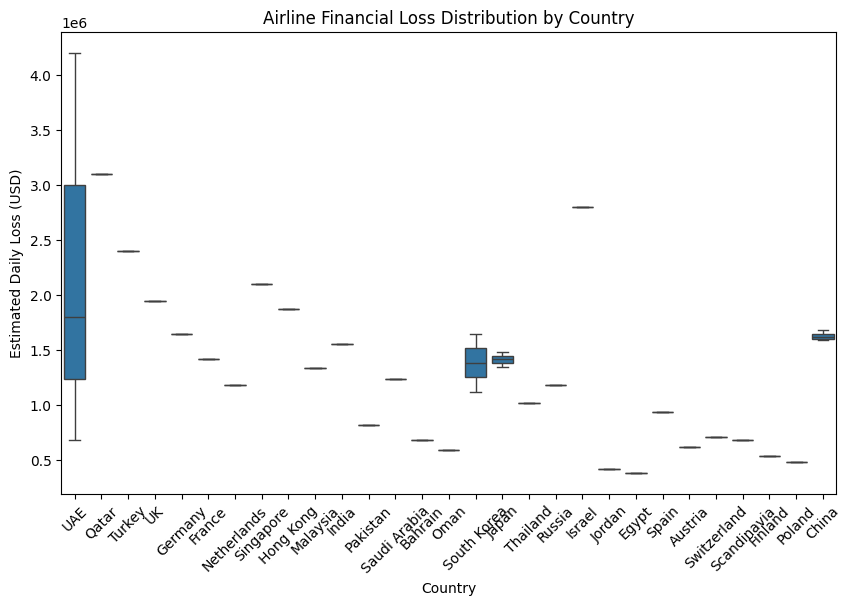

In [72]:
#Country Loss Distribution: This shows which countries experience the highest airline losses.
plt.figure(figsize=(10,6))

sns.boxplot(x='country', y='estimated_daily_loss_usd', data=airline)

plt.title("Airline Financial Loss Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Estimated Daily Loss (USD)")

plt.xticks(rotation=45)

Text(0, 0.5, 'Estimated Daily Loss (USD)')

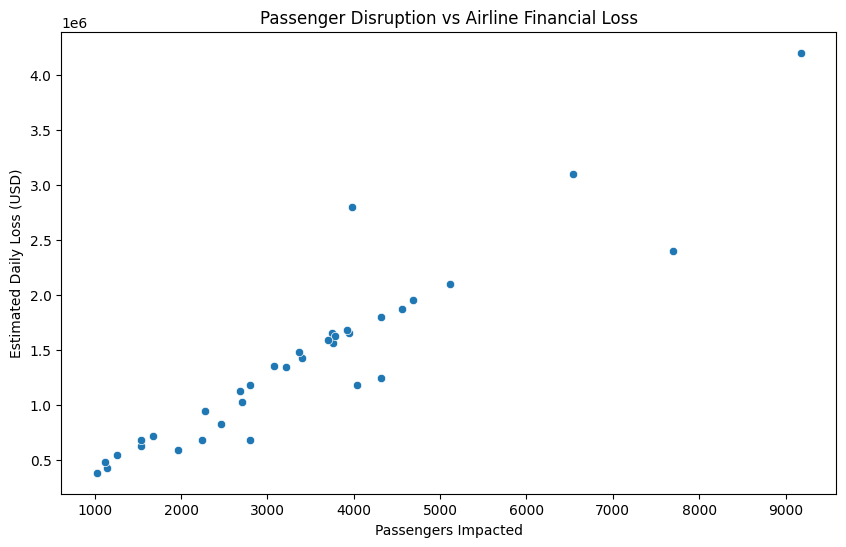

In [73]:
#Relationship Between Passengers Impacted and Loss: This visual explains how disruption size affects losses.
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='passengers_impacted',
    y='estimated_daily_loss_usd',
    data=airline
)

plt.title("Passenger Disruption vs Airline Financial Loss")
plt.xlabel("Passengers Impacted")
plt.ylabel("Estimated Daily Loss (USD)")

Text(0, 0.5, 'Predicted Loss (USD)')

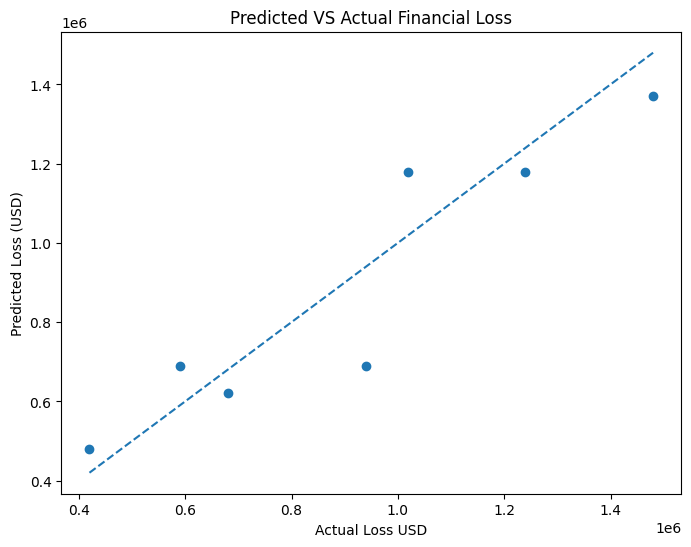

In [79]:
#Relationship Between Passengers Impacted and Loss: This visual explains how disruption size affects losses using line of best fit.
plt.figure(figsize = (8,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle = "--")
plt.title("Predicted VS Actual Financial Loss")
plt.xlabel("Actual Loss USD")
plt.ylabel("Predicted Loss (USD)")

The Actual vs Predicted plot shows that most predictions lie close to the diagonal reference line, indicating that the model captures the overall trend in airline financial losses. While some deviations exist, the model generally predicts losses within a reasonable range, consistent with the strong R² score of 0.856.
